 Employee Attrition Prediction using Machine Learning

Name: Dharani Kankanala

Internship: XYlofy AI Internship Program

Project: Week 2 – Employee Attrition Prediction

Objective: To build a Machine Learning system that predicts whether an employee is likely to leave the company based on factors like job satisfaction, salary, work-life balance, years at the company, and performance ratings.


 **Task 1: Data Loading & **Exploration****

In [253]:
# Import Libraries #
import pandas as pd
import numpy as np

In [254]:
# Load the CSV File #
df = pd.read_csv("/content/HR_Attrition.csv")


In [255]:
# Display the First 10 Rows #
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [256]:
# Shape Of Dataset #
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1470, 35)
Number of Rows: 1470
Number of Columns: 35


In [257]:
# Target Column #
print("Target Column:", "Attrition")
print(df["Attrition"].unique())

Target Column: Attrition
['Yes' 'No']


In [258]:
# Count Of Left vs Stayed Employees #
attrition_count = df["Attrition"].value_counts()
print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [259]:
# Attrition Rate #
attrition_rate = (df["Attrition"] == "Yes").mean() * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [260]:
# Numeric and Categorical Columns #
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns
print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))
print("\nNumeric Columns:")
print(list(numeric_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


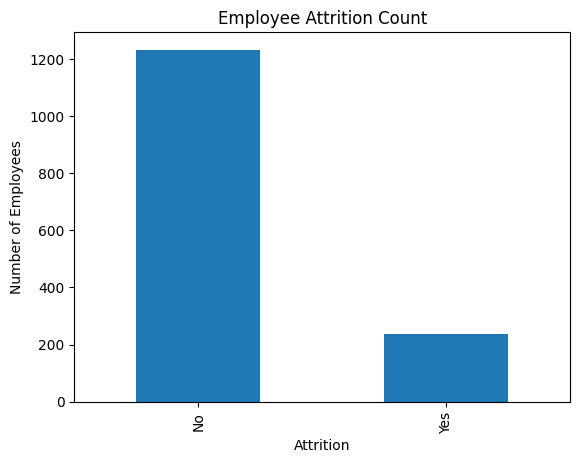

In [261]:
# Visualization #
import matplotlib.pyplot as plt
attrition_count.plot(kind="bar")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

**Observation:-**

The dataset is imbalanced. Around 84% of employees stayed with the company, while only about 16% left. This class imbalance should be considered during model training and evaluation because a model may become biased toward predicting the majority class.

**Task 2: Data Cleaning & Preprocessing**

In [262]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [299]:
# Check Missing Values #
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [ ]:

print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [265]:
# Drop irrelavent columns #
df.drop(
    columns=[
        'EmployeeNumber',
        'EmployeeCount',
        'Over18',
        'StandardHours'
    ],
    inplace=True
)
print(df.shape)

(1470, 31)


In [266]:
# Convert Attrition #
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [267]:
# Separate Features #
X = df.drop('Attrition', axis=1)
y = df['Attrition']
# Categorical Columns #
categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)


Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [268]:
# One-Hot Encoding #
X = pd.get_dummies(
    X,
    drop_first=True
)
print(X.shape)

(1470, 44)


In [269]:
# Numeric Features #
numeric_cols = X.select_dtypes(include=['int64','float64']).columns
print("Numeric Features:", len(numeric_cols))

Numeric Features: 23


In [270]:
# Scaling #
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)
X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


In [271]:
# Shape of Features & Targets #
print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


**Task 3 — Exploratory Data Analysis**

Attrition Rate by Department

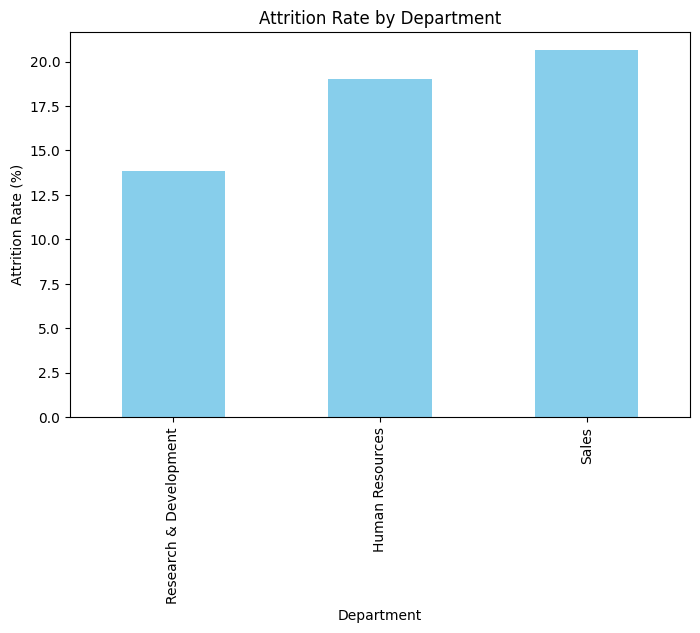

In [272]:
import matplotlib.pyplot as plt
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100
dept_attrition
plt.figure(figsize=(8,5))

dept_attrition[1].sort_values().plot(
    kind='bar',
    color='skyblue'
)
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.show()

Typically:

Sales ≈ 20.6% Human Resources ≈ 19% Research & Development ≈ 13.8%

Sales department loses the most employees.




Attrition rate by Job

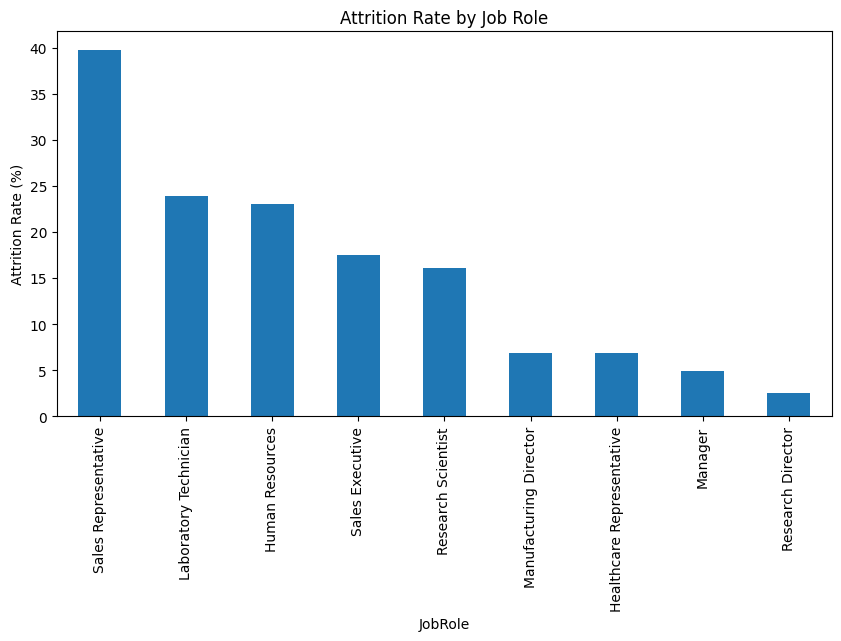

In [273]:
job_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100
job_attrition.sort_values(by=1, ascending=False)
plt.figure(figsize=(10,5))
job_attrition[1].sort_values(
    ascending=False
).plot(kind='bar')
plt.title('Attrition Rate by Job Role')
plt.ylabel('Attrition Rate (%)')
plt.show()

Highest attrition roles:

Sales Representative ≈ 39.8%
Laboratory Technician ≈ 23.9%
Human Resources ≈ 23.1%

Attrition vs Monthly Income

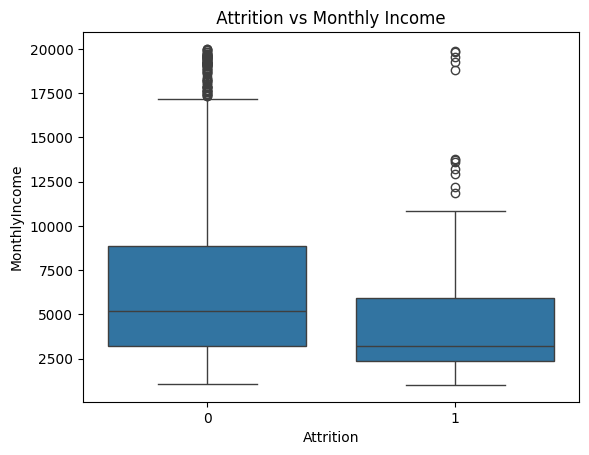

,MonthlyIncome
Attrition,
0,6832.739659
1,4787.092827


In [274]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.title(' Attrition vs Monthly Income ')
plt.show()
df.groupby('Attrition')['MonthlyIncome'].mean()

Employees who left generally earn significantly less than employees who stayed

Attrition vs Work-Life Balance

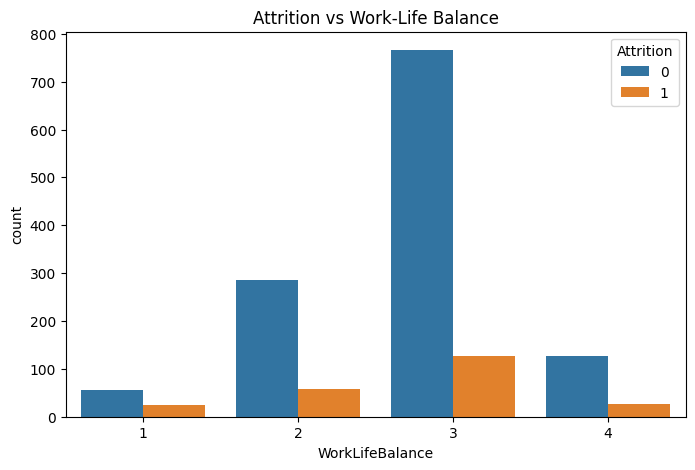

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [275]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title('Attrition vs Work-Life Balance')
plt.show()
pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
) * 100

Lower work-life balance ratings tend to show higher attrition rates.

Attrition vs Years at Company

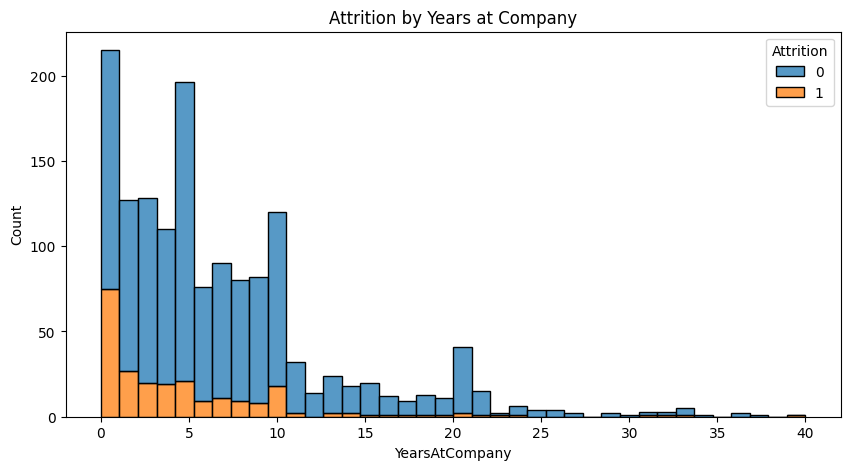

,YearsAtCompany
Attrition,
0,7.369019
1,5.130802


In [276]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)
plt.title('Attrition by Years at Company')
plt.show()
df.groupby('Attrition')['YearsAtCompany'].mean()

Most employee exits occur during the first 5 years.

**Business Insights**

1. Sales department has the highest attrition rate among all departments, indicating a need for stronger employee engagement and retention strategies.
2. Sales Representatives and Laboratory Technicians experience noticeably higher attrition than other job roles, suggesting these positions may face greater workload or career progression challenges.
3. Employees with lower monthly incomes are more likely to leave the company, indicating that compensation may be an important factor influencing attrition.
4. Employees with lower Work-Life Balance ratings (1–2) show higher attrition compared with those reporting better work-life balance (3–4), highlighting the importance of workplace flexibility and employee well-being.
5. Attrition is concentrated among employees with fewer years at the company, especially during the first five years, suggesting that onboarding, mentoring, and early-career support could significantly improve retention.

**Task 4 - Model Building & Comparision**

In [277]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (1176, 44)
Testing Set: (294, 44)


In [278]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [279]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [280]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [281]:
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [282]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [283]:
from sklearn.metrics import accuracy_score
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)
print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)
print("Gradient Boosting:", gb_acc)

Logistic Regression: 0.7482993197278912
Random Forest: 0.8435374149659864
Gradient Boosting: 0.8503401360544217


In [284]:
comparison_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        lr_acc,
        rf_acc,
        gb_acc
    ]
})
comparison_table.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Gradient Boosting,0.850340
1,Random Forest,0.843537
0,Logistic Regression,0.748299


**Task 5 - Moodel Evaluation**

In [285]:
# Import Evaluation Metrics #
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

ROC-AUC: 0.798604530967353


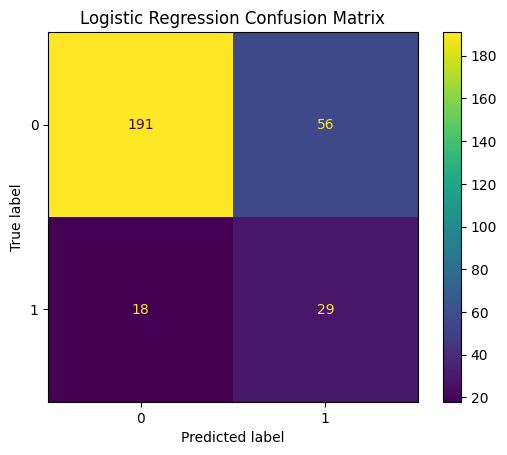

In [286]:
# Logistic Regression #
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))
lr_auc = roc_auc_score(y_test, lr_prob)
print("ROC-AUC:", lr_auc)
cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr
).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

ROC-AUC: 0.7716426910155914


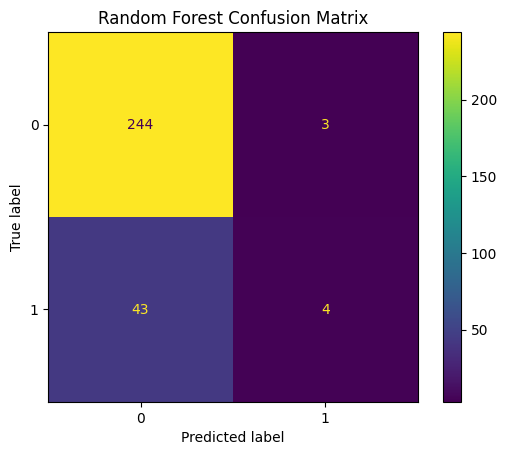

In [287]:
# Random Forest #
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print("RANDOM FOREST")
print(classification_report(y_test, rf_pred))
rf_auc = roc_auc_score(y_test, rf_prob)
print("ROC-AUC:", rf_auc)
cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

ROC-AUC: 0.7941252476526832


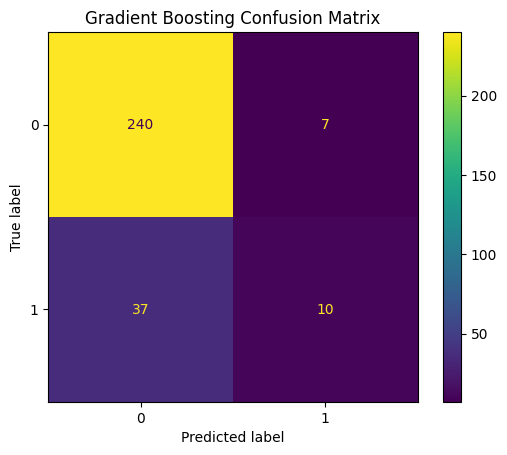

In [288]:
# Gradient Boosting #
gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:,1]
print("GRADIENT BOOSTING")
print(classification_report(y_test, gb_pred))
gb_auc = roc_auc_score(y_test, gb_prob)
print("ROC-AUC:", gb_auc)
cm_gb = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm_gb
).plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [289]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Precision':[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    'Recall':[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    'F1 Score':[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    'ROC-AUC':[
        lr_auc,
        rf_auc,
        gb_auc
    ]
})
results.sort_values(
    by='ROC-AUC',
    ascending=False
)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125
1,Random Forest,0.571429,0.085106,0.148148,0.771643


In [290]:
results.sort_values(
    by='ROC-AUC',
    ascending=False
).head(1)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605


In [291]:
# Feature Importance #
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.074990
0,Age,0.064265
1,DailyRate,0.054629
16,TotalWorkingYears,0.051717
19,YearsAtCompany,0.050516
10,MonthlyRate,0.046254
5,HourlyRate,0.044628
43,OverTime_Yes,0.043875
22,YearsWithCurrManager,0.042047
2,DistanceFromHome,0.041556


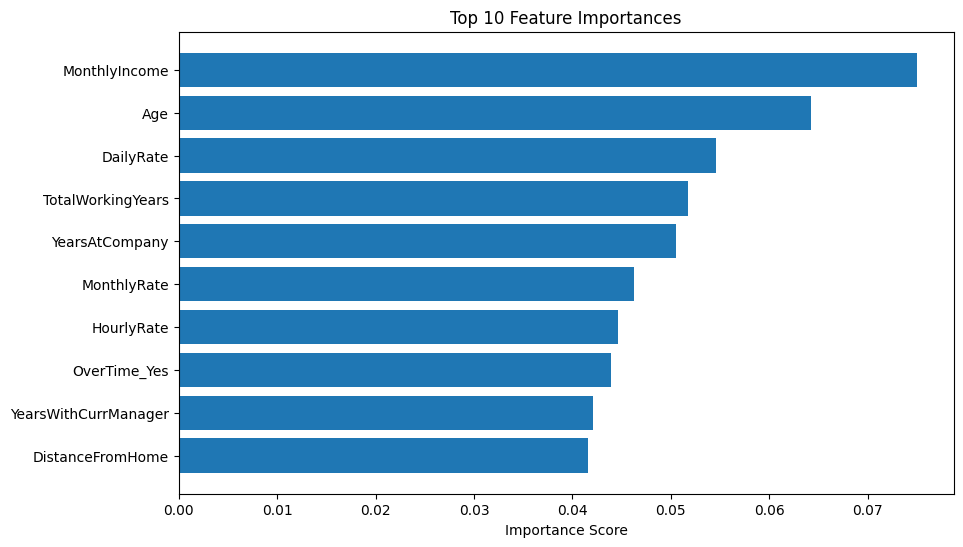

In [292]:
# Plot Top 10 Features #
top10 = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10['Feature'],
    top10['Importance']
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

**Task 6 - Visualization**

Chart 1 : Attrion Rate by Department

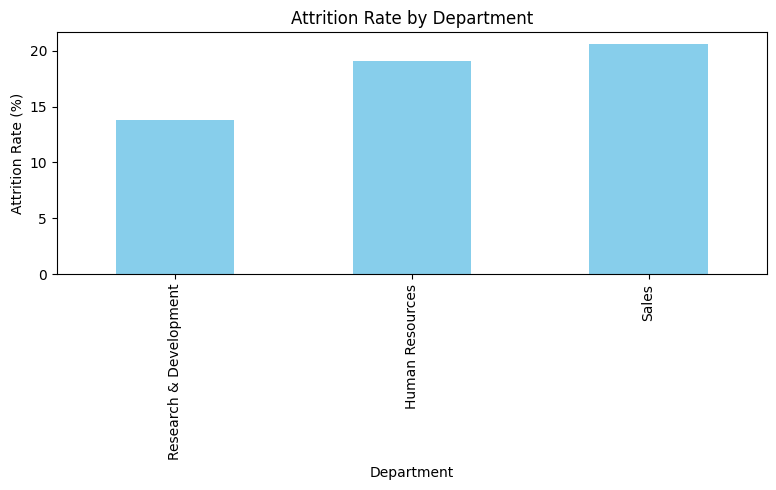

In [293]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100
# Department-Wise Attrition #
plt.figure(figsize=(8,5))
dept_attrition[1].sort_values().plot(
    kind='bar',
    color='skyblue'
)
plt.title('Attrition Rate by Department')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Department')
plt.tight_layout()
# Create the directory if it doesn't exist
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/chart1_department_attrition.png')
plt.show()

Chart 1B : Attrition Rate by Job Role

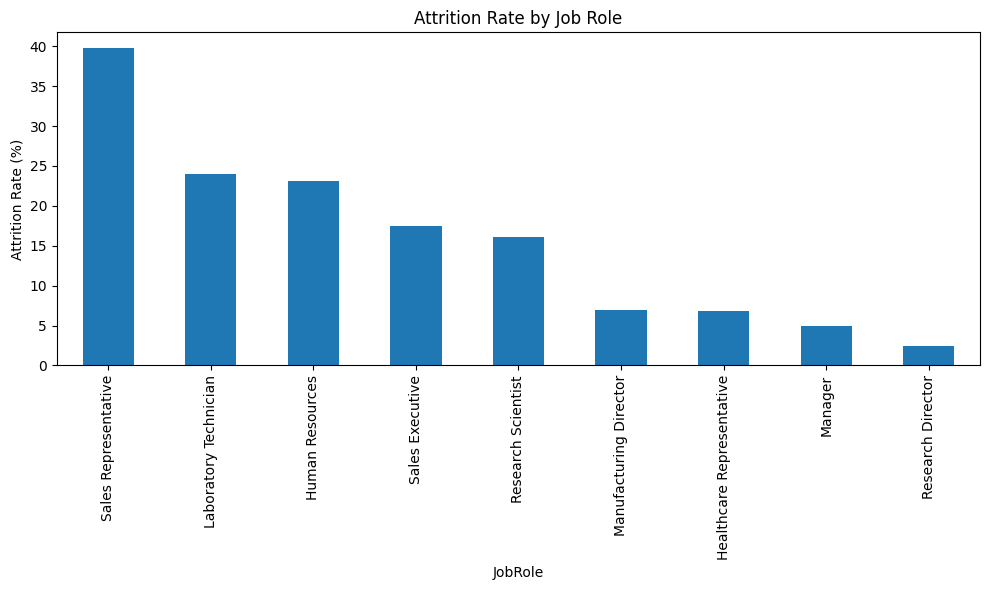

In [294]:
job_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100
#Job Role-Wise Attrition #
plt.figure(figsize=(10,6))
job_attrition[1].sort_values(
    ascending=False
).plot(kind='bar')
plt.title('Attrition Rate by Job Role')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('charts/chart1_jobrole_attrition.png')
plt.show()

Chart 2 : Monthly Income vs Attrition (Box Plot)

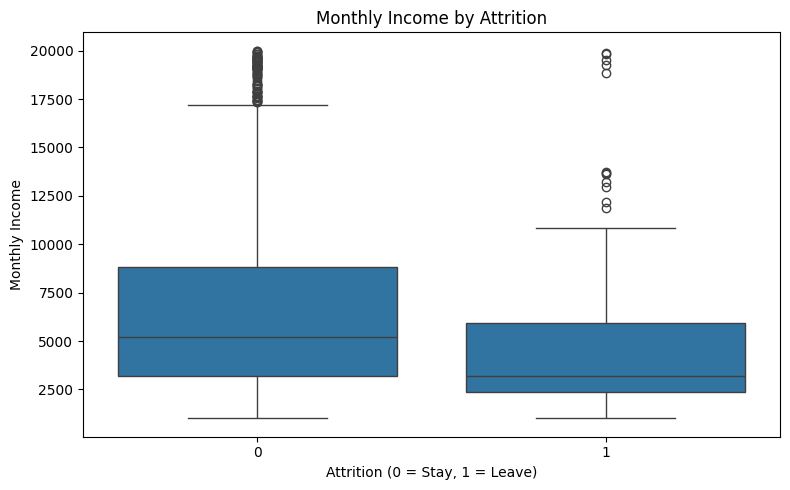

In [295]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition (0 = Stay, 1 = Leave)')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png')
plt.show()

Chart 3: Confusion Matrix Heatmap (Best Model)

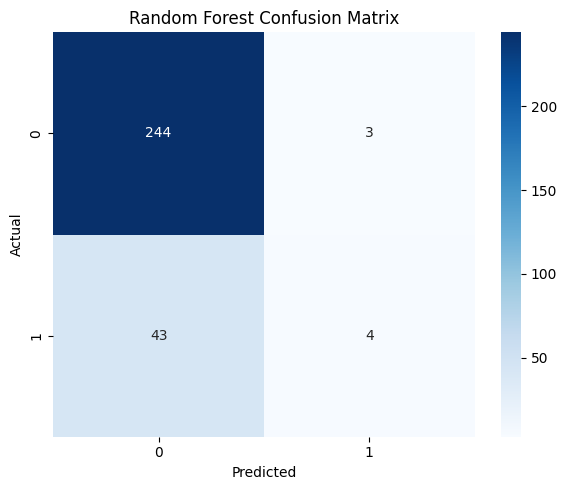

In [296]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png')
plt.show()

Chart 4: Top 10 Feature Importances

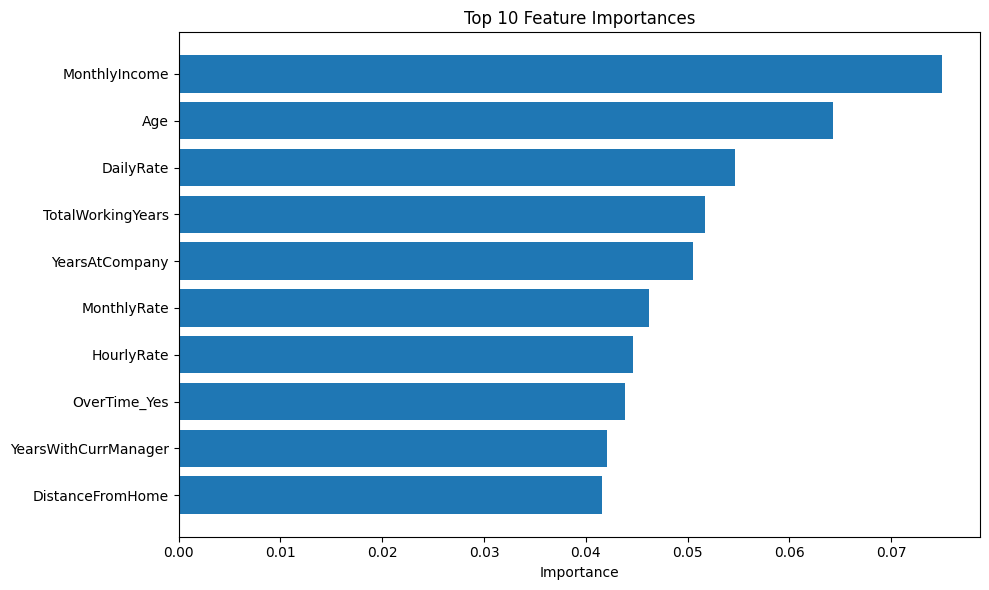

In [297]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
top10 = importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top10['Feature'],
    top10['Importance']
)
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png')
plt.show()


Chart 5 (Bonus): ROC Curve Comparison

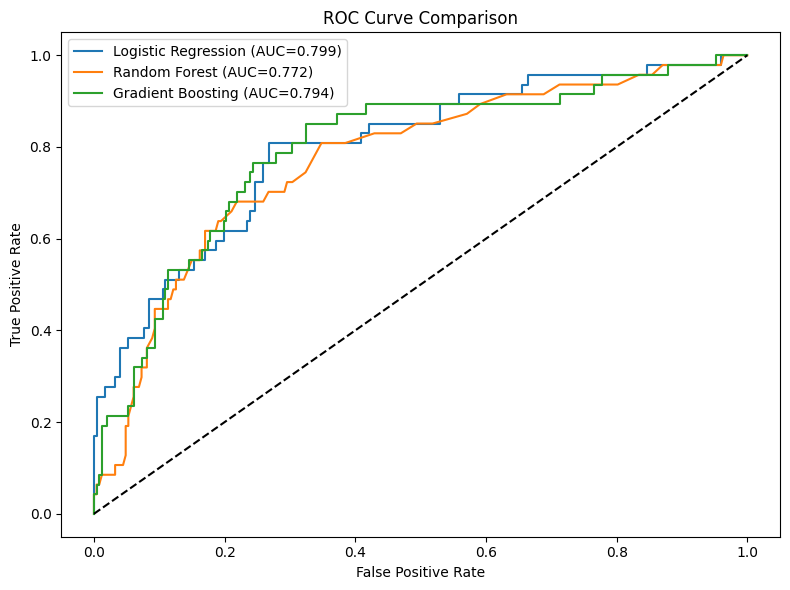

In [298]:
from sklearn.metrics import roc_curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
plt.figure(figsize=(8,6))
plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC={lr_auc:.3f})'
)
plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC={rf_auc:.3f})'
)
plt.plot(
    gb_fpr,
    gb_tpr,
    label=f'Gradient Boosting (AUC={gb_auc:.3f})'
)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png')
plt.show()

**Task 7 - HR Insights & Business Recommendations**

HR Insights & Business Recommendations

The analysis indicates that employee attrition is influenced by multiple factors rather than a single reason. Among the most important predictors are OverTime, MonthlyIncome, and YearsAtCompany (your feature importance results may show slightly different top features). Employees working overtime, earning lower salaries, or having fewer years at the company tend to have a higher probability of leaving. The Sales department and roles such as Sales Representative and Laboratory Technician generally experience higher attrition and should be prioritized for retention initiatives.

Salary alone does not fully explain employee attrition. Factors such as overtime, work-life balance, job satisfaction, career growth, and tenure also have a significant impact on whether employees decide to leave.

HR Recommendations:

1. Introduce targeted retention programs for employees identified as high-risk, especially those in their first few years, including mentoring, career development plans, and regular one-on-one check-ins.


2. Reduce excessive overtime by balancing workloads and improving work-life balance while reviewing compensation and promotion opportunities for employees in high-attrition roles.